# Is openness before take-off brokerage or churn? — demo notebook

**Artifact:** `art_htO_gJuUn6Pr` (RQ1 deepen, iteration 3, CPU only, $0).

**Question.** In the iteration-2 co-word networks, emerging scientific concepts had *less closed* top neighbourhoods
(lower `closure`) in the years before their take-off (`E_up` = sustained uptake). Is that openness **brokerage**
(the concept spans otherwise disconnected parts of science, in the sense of Burt), or **churn/turnover** (its
neighbour set is replaced every year, so closure is low mechanically)?

**How the experiment answers it.** Concepts are re-attached to the iteration-2 snapshots and four turnover-proof
openness measures are computed next to raw closure:

| row | measure | idea |
|---|---|---|
| R1a | `closure_resT` | closure residualised on turnover covariates (label-free OLS) |
| R1b | `closure_persist` | closure on neighbours present in both top-20(y) and top-20(y-1) |
| R1c | `constraint`, `effsize`, `xc_excess` | Burt constraint / effective size of the weighted ego network, cross-community pair excess |
| R1d | hub-not-clique | `wmz` up while `closure` goes down |

A **matched event study** compares each take-off concept with up to 3 never-take-off controls (same field band,
origin group and ±20% volume). The effect **S** is the mean treated−control difference over k = −3..0 years before
onset, with a bootstrap CI. A **pre-registered mechanical rule** then labels the pattern BROKERAGE / TURNOVER / MIXED.

**What this notebook runs.** The original `method.py` chains 19 subprocess steps. Steps 0–4 re-attach concepts to
large co-word snapshots (several GB, not shipped). This demo starts from the *output* of those steps: a
100-concept subset of the concept-year indicator panel in `mini_demo_data.json`. It then re-runs the analysis
code unchanged:

* **R1c check** — `ego_brokerage` against networkx on random ego graphs;
* **Step 4 (R1a)** — the frozen label-free OLS applied to the panel;
* **Step 5** — `E_up` / `E_alt` / `E` labels and onset groups;
* **Step 6** — the matched event study, Holm family, H-matched sensitivity, pooled panel and placebo;
* **Step 7** — the mechanical verdict.

The demo subset holds every matched treated concept of the primary cell and every never-emerging control. So with
the original bootstrap size, the primary S values and CIs are **the same numbers as the full run**.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru — NOT on Colab, always install (the original scripts log with it)
_pip('loguru==0.7.3')

# numpy, pandas, scipy, networkx, matplotlib — pre-installed on Colab, install locally only
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scipy==1.16.3', 'networkx==3.6.1', 'matplotlib==3.10.0')

In [2]:
# --- original method.py import block ---
from __future__ import annotations

import os

os.environ.setdefault("OMP_NUM_THREADS", "1")

import argparse  # noqa: E402
import subprocess  # noqa: E402
import sys  # noqa: E402
import time  # noqa: E402
from pathlib import Path  # noqa: E402

from loguru import logger  # noqa: E402

# --- imports used by the src/ and vendor/ modules that method.py orchestrates ---
import hashlib
import json
import math
import types
import warnings
from collections.abc import Iterable, Sequence

import numpy as np
import pandas as pd
import scipy.sparse as sp

# --- notebook-only additions (verification + plots) ---
import networkx as nx
import matplotlib.pyplot as plt

logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")

1

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/ai-inventor-papers/ai-invention-8892b7-occupancy-is-not-integration-for-new/fork/run_desxWCcMY1R1/round-3/experiment-5/demo/mini_demo_data.json"
import json
from pathlib import Path

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception: pass
    local = Path("mini_demo_data.json")
    if local.exists(): return json.loads(local.read_text())
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["selection"])
print("concepts:", len(data["concepts"]), "| concept-years:", sum(len(c["panel"]["year"]) for c in data["concepts"]))

100 MAIN screen-fold concepts: all 26 E_up-emerging concepts matched in the primary cell, all 70 E_up-never concepts (superset of every matched control), and 4 unmatched E_up onsets.
concepts: 100 | concept-years: 1787


## Configuration

Every tunable parameter is in this one cell. The only costly parts of the analysis are bootstrap loops and the
number of random graphs in the R1c check.

* `BOOTSTRAP` — resamples for the primary cell, H-matched, pooled panel and placebo (original **2000**, `SPEC3["bootstrap"]`).
* `BOOTSTRAP_NONPRIMARY` — resamples for the secondary grid cells used by the verdict flags (original **2000**).
* `N_TOY_GRAPHS` — random ego networks used to check `ego_brokerage` against networkx (original test suite: **50**).

With `BOOTSTRAP = 2000` the primary point estimates **and** CIs equal the full-run numbers. Smaller values keep
the point estimates S exactly but give noisier CIs.

In [5]:
BOOTSTRAP = 2000              # original: 2000
BOOTSTRAP_NONPRIMARY = 2000   # original: 2000
N_TOY_GRAPHS = 50            # original (tests/test_openness.py): 50

## The original orchestrator (`method.py`)

`method.py` is only an orchestrator. It runs each step of `src/` as a subprocess in a fixed, pre-declared order.
Its docstring and step list are reproduced below. A notebook cannot re-run steps 0–4 without the multi-GB
snapshots of the dependency artifacts, so the cell only prints which steps this demo re-executes in-process.

```text
Is openness before take-off brokerage or churn? RQ1 deepen (iteration 3), $0, CPU only.

Pipeline (each step is a module in src/; this script orchestrates them in the pre-declared order):
  0  setup       vendor exp_3 code byte-identical, hash, write prereg_v3.json BEFORE any label
  1  population  frozen replacement rule -> MAIN / STRICT / SENS; folds (sha1 rule == ds5), old/new
  2  prep3       dataset_5 c-papers (active + sealed held-out), totals, data-change check vs exp_3
  3  attach      re-attach concepts to the exp_3 snapshots (modes repro_code, repro_data, full) + R1b / R1c metrics
  4  indicators  vendored concept_indicators + new columns + R1a (label-free) ; repro gate ; sealed held-out pass
  5  labels3     E_up / E_alt / E on the screen fold only (held-out ids loaded into the vendored guard)
  -  leakage     new + vendored features recomputed with data after t removed
  6  event3      matched event study grid, primary family (Holm), sensitivities, panels, R1a correlations, R1d
  7  verdict     mechanical BROKERAGE / TURNOVER / MIXED
  8  power       held-out MDE (event study vs pooled panel) -> held-out primary estimator
  9  predict3    grouped-CV delta-AUC, reported not claimed
  10 figs, audit, exports, confirm self-test, freeze (heldout_spec.json, last: it hashes all code)

Usage:
  uv run method.py              # full pipeline (~10 min on 4 CPUs)
  uv run method.py --from 5     # rerun from the labels step (inputs from earlier steps must exist)
```

In [6]:
# original step list from method.py main() (workers argument fixed to "1" here)
K_SEALED_MAX_YEAR = 2015  # K.SPEC3["sealed_max_year"]
w = "1"
steps = [
    (0, ["src/setup.py"]),
    (1, ["src/population.py"]),
    (2, ["src/prep3.py"]),
    (3, ["src/attach.py", "--modes", "full", "repro_code", "repro_data", "--workers", w]),
    (4, ["src/indicators3.py", "--modes", "repro_code", "repro_data", "full", "--workers", w]),
    (4, ["src/repro.py"]),
    (4, ["src/attach.py", "--modes", "sealed", "--years"] + [str(y) for y in range(2000, K_SEALED_MAX_YEAR + 1)]
     + ["--workers", w]),
    (4, ["src/indicators3.py", "--modes", "sealed", "--workers", w]),
    (5, ["src/labels3.py"]),
    (5, ["src/leakage.py"]),
    (6, ["src/event3.py"]),
    (7, ["src/verdict.py"]),
    (8, ["src/power.py"]),
    (9, ["src/predict3.py"]),
    (10, ["src/figs.py"]),
    (10, ["src/audit.py"]),
    (10, ["confirm_heldout.py", "--self-test-on-screen"]),
    (10, ["src/exports.py"]),
    (10, ["src/freeze.py"]),
]
# steps re-executed in-process below (R1c only as the networkx unit check; R1a with the frozen betas)
IN_DEMO = {"src/labels3.py": "Step 5", "src/event3.py": "Step 6", "src/verdict.py": "Step 7"}
for k, args in steps:
    tag = IN_DEMO.get(args[0], "")
    if args[0] == "src/indicators3.py" and "full" in args:
        tag = "Step 4 (R1a apply)"
    if args[0] == "src/attach.py" and "full" in args:
        tag = "R1c check only"
    print(f"step {k:>2}: {' '.join(args)[:88]:<88} {'<- demo: ' + tag if tag else ''}")

step  0: src/setup.py                                                                             
step  1: src/population.py                                                                        
step  2: src/prep3.py                                                                             
step  3: src/attach.py --modes full repro_code repro_data --workers 1                             <- demo: R1c check only
step  4: src/indicators3.py --modes repro_code repro_data full --workers 1                        <- demo: Step 4 (R1a apply)
step  4: src/repro.py                                                                             
step  4: src/attach.py --modes sealed --years 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2 
step  4: src/indicators3.py --modes sealed --workers 1                                            
step  5: src/labels3.py                                                                           <- demo: Step 5
step  5: src/leakage.py                     

## Frozen specifications: `SPEC` (vendored iteration-2 `config.py`) and `SPEC3` (`src/common.py`)

`SPEC` is the iteration-2 spec, vendored byte-identical. The event-study window, matching calipers and label
thresholds come from it. `SPEC3` was pre-registered (`prereg_v3.json`, sha256 `2f46d173…`) **before any label
was computed**. It fixes the rows, directions, seeds and the verdict rule text. Only the bootstrap sizes are
overridden, from the config cell.

In [7]:
SPEC: dict = dict(
    years=list(range(2000, 2025)), window=3, tag_min_score=0.3, min_level=1, kept_edge_min_raw=2,
    leiden=dict(type="RBConfiguration", resolution=1.0, seed=42, n_runs=5),
    alluvial_min_jaccard=0.3, alluvial_min_comm_size=5,
    topk_closure=20, closure_min_neighbours=5, rewire_n=20, rewire_snapshots=[2008, 2013, 2018],
    stability_resamples=20, stability_snapshots=[2008, 2013, 2018],
    betweenness_pivots=500, rarefy_m=10, rarefy_m_sensitivity=5, rarefy_draws=50,
    E_uptake_mean=20, E_max_fall=0.30, E_pct_gain=20, ages=[3, 8], t_max=2019,
    sealed_focal_years=[2016, 2017, 2018], screen_onset_years=list(range(2008, 2016)),
    match=dict(band=True, origin_group=True, vol_caliper=0.20, widen=0.30, ratio=3, replace=True),
    bootstrap=1000, holm_precursors=["accretion_shift_rar", "closure", "P_rar"],
    precursor_signs={"accretion_shift_rar": "+", "closure": "+", "P_rar": "+"},
    es_rel_years=list(range(-5, 1)), es_summary_window=[-3, 0],
    test_origins=[2013, 2014, 2015, 2019], min_train_rows=30, min_train_pos=5,
    h3_test_origins=[2011, 2012, 2013, 2014, 2015, 2019],
    frame_types=["article", "review", "preprint", "book-chapter"],
    kleinberg=dict(s=2.0, gamma=1.0),
    sensitivity_grid=dict(uptake=[10, 20, 30], pct_gain=[10, 20, 30]),
    early_bridging=dict(P_raw=0.6, btw_pct=90, min_comm_share=0.10, min_comms=2),
    gradual_centralisation=dict(min_len=3, tau=0.5, P_max=0.3),
    incubation=dict(min_run=2, burst_pct=90),
    typology=dict(channels=["strength_growth", "beta_sim_rar", "beta_sne_rar", "P_rar", "closure", "btw_pct", "H"],
                  ages=list(range(0, 9)), max_missing=3, max_fill=2, k_range=[2, 3, 4, 5, 6],
                  sakoe_chiba_radius=2, boot=200, jaccard_min=0.75),
    clarifications=[
        "(i) kept-graph edges = >= 2 RAW sample co-occurrences in the 3-year window (weighted c_ij >= 2 is non-binding because "
        "design weights are >= 1, median 293); strengths use ALL edges.",
        "(ii) background-comparable pool quantities (strength, strength percentile, association strength, closure neighbour "
        "set, within-module z, betweenness attachment) use frame-type c-papers (article, review, preprint, book-chapter); "
        "volume, uptake, neighbourhood turnover (Baselga, novelty), participation/community touch and disciplinary "
        "diversity/incidence use all c-paper types.",
        "(iii) works with topic_score < 0.05 (default-topic hazard H1) get subfield 'unknown' in the concept-subfield view "
        "only and are excluded from diversity measures; they stay in the co-word network.",
        "(iv) 'cross-community betweenness' (early bridging) = betweenness percentile >= 90 on the kept graph AND the node's "
        "frame-type tag weight touches >= 2 communities with >= 10% each.",
        "(v) background yearly weights are post-stratified w_year = n_frame(s,y)/n_sampled(s,y); design weight is the "
        "fallback when a subfield-year has no post-stratification cell.",
        "(vi) residualised (_res) indicator versions are fit on the full screen panel and are used only in the event "
        "study, never as prediction features (avoids pooled look-ahead).",
        "(vii) the pool concept strength percentile is computed among all nodes of snapshot y (background legacy concepts "
        "+ attached pool concepts); ALT percentile is among pool (screen+reference) nodes only.",
    ],
)

SEALED_IDS: set[str] = set()

def assert_not_sealed(concept_ids, focal_years=()) -> None:
    """Code guard: held-out concepts and sealed focal years never enter E/W2 computations."""
    bad = set(concept_ids) & SEALED_IDS
    if bad:
        raise RuntimeError(f"SEALED concept ids requested: {sorted(bad)[:5]}")
    bad_t = set(int(t) for t in focal_years) & set(SPEC["sealed_focal_years"])
    if bad_t:
        raise RuntimeError(f"SEALED focal years requested: {sorted(bad_t)}")

In [8]:
VERDICT_RULES = (
    "BROKERAGE if ALL of: S_res < 0 and CI_res excludes 0; |S_res| >= 0.5*|S_raw|; S(closure_persist) < 0; "
    "S(constraint) < 0; (CI(closure_persist) excludes 0 OR CI(constraint) excludes 0). "
    "TURNOVER if ALL of: CI_res includes 0; |S_res| < 0.5*|S_raw|; R1b null (CI(closure_persist) includes 0). "
    "MIXED otherwise. R1b NON-ESTIMABLE (< 10 matched treated with finite closure_persist in k=-3..0) counts as null "
    "for TURNOVER and as failing for BROKERAGE. S_raw = S(closure), S_res = S(closure_resT), cell = MAIN x all x E_up "
    "x route all. Flags never change the label: R1c_degree_driven, R1b_selection, H_sensitive, underpowered, "
    "fresh_replication, route_B_only agreement, R1a_model_dependent."
)


SPEC3: dict = dict(
    bootstrap=2000, bootstrap_nonprimary=2000, es_primary_window=[-3, 0], es_sens_window=[-5, -1],
    es_rel_years=list(range(-5, 1)), persist_min=5, xcomm_null_draws=50, xcomm_strength_deciles=10,
    ego_min_neighbours=5, xc_min_members=5,
    r1a_covariates=["new_relation_rate", "novelty", "beta_sim_rar", "log_vol3", "age", "H"],
    r1a_na_rule="mean-fill (screen fit-set mean) + NA dummy for any covariate with missing values "
                "(beta_sim_rar and H by declaration; novelty / new_relation_rate if NA occurs)",
    r1a_fit_set="arm main, fold screen, finite closure, age >= -2 (all years); NO label column in scope",
    r1a_sensitivities={"closure_resT_cc": "complete-case (no fill, no dummies)",
                       "closure_resT_raw": "beta_sim_raw replaces beta_sim_rar (mean-fill + NA dummy)"},
    holm_primary=["closure_resT", "closure_persist", "constraint"],
    screened_direction={"closure": "-", "closure_resT": "-", "closure_persist": "-", "constraint": "-",
                        "xc_excess": "+", "effsize": "+", "wmz": "+"},
    verdict_rules=VERDICT_RULES,
    r1b_min_treated=10, r1b_selection_points=15, h_sensitive_loss=0.5, underpowered_n=30,
    match_H_sensitivity_caliper_sd=0.25,
    betweenness_seed_base=20260928, betweenness_pivots=500,
    sealed_max_year=2015,
    seeds=dict(es=20261001, panel=7, cv=11, sim=13, xc="XC"),
    mde=dict(grid_n=25, grid_max_sd=1.5, sims=500, boot=400, power=0.80, alpha_one_sided=0.05,
             tie_rel=0.05),
    prediction=dict(ages=[3, 8], t_range=[2008, 2015], folds=5, seeds=[0, 1, 2, 3, 4], C=1.0, boot=2000,
                    shuffles=20, label="E_up", population="MAIN screen",
                    BASE="vendored analysis_predict BASELINE = BASE_A + BASE_B + BASE_C + EXTRA",
                    FULL="BASE + [closure_resT (R1a OLS refit inside each training fold), constraint]",
                    FULL_R1bc="BASE + [closure_persist (median-fill + NA dummy), xc_excess]",
                    model="StandardScaler + L2 logistic C=1, class_weight balanced (vendored _clf('logit'))",
                    cv="StratifiedGroupKFold(5, shuffle, groups=concept) x 5 seeds; OOF scores averaged over seeds"),
    populations=dict(MAIN="frozen MAIN rule after the frozen replacement rule", STRICT="frozen STRICT rule",
                     SENS="all 426 (screen part = 247 screen-fold main concepts)"),
    fold_rule="int(sha1(concept_id).hexdigest(), 16) % 10 < 7 -> screen else heldout (ds5 metadata_fold authoritative)",
)

# ---- demo override of the bootstrap sizes (see the config cell) ----
SPEC3["bootstrap"] = BOOTSTRAP
SPEC3["bootstrap_nonprimary"] = BOOTSTRAP_NONPRIMARY
print("es window", SPEC["es_rel_years"], "primary", SPEC3["es_primary_window"], "| B =", SPEC3["bootstrap"])

es window [-5, -4, -3, -2, -1, 0] primary [-3, 0] | B = 2000


## Pure helper functions (vendored `lib_metrics.py`)

Deterministic seeds (`stable_seed` hashes its parts with sha1, so it does not depend on PYTHONHASHSEED),
standardised mean difference and the Holm adjustment.

The original code lives in separate modules that import each other (`import common as K`,
`import analysis_event as AE`, `import lib_metrics as lm`, `import config as C`). In this single notebook,
`_register_module` registers the notebook's functions under those module names. The original import lines then
run **unchanged**.

In [9]:
def stable_seed(*parts: object) -> int:
    """Deterministic 32-bit seed from arbitrary parts (independent of PYTHONHASHSEED)."""
    h = hashlib.sha1("|".join(map(str, parts)).encode()).hexdigest()
    return int(h[:8], 16)


def smd(a: Sequence[float], b: Sequence[float]) -> float:
    """Standardised mean difference with pooled SD."""
    a = np.asarray(a, dtype=float)
    b = np.asarray(b, dtype=float)
    a, b = a[np.isfinite(a)], b[np.isfinite(b)]
    if a.size < 2 or b.size < 2:
        return math.nan
    sd = math.sqrt((a.var(ddof=1) + b.var(ddof=1)) / 2.0)
    if sd == 0:
        return 0.0
    return float((a.mean() - b.mean()) / sd)


def holm(pvals: Sequence[float]) -> list[float]:
    """Holm step-down adjusted p-values (NaN entries passed through)."""
    p = np.asarray(pvals, dtype=float)
    out = np.full_like(p, np.nan)
    ok = np.where(np.isfinite(p))[0]
    order = ok[np.argsort(p[ok])]
    m = len(order)
    running = 0.0
    for rank, idx in enumerate(order):
        adj = min(1.0, (m - rank) * p[idx])
        running = max(running, adj)
        out[idx] = running
    return out.tolist()


def _register_module(name: str, **attrs) -> types.ModuleType:
    # notebook glue: expose notebook-defined objects under the original module name so `import <name>` works
    mod = sys.modules.get(name) or types.ModuleType(name)
    for k, v in attrs.items():
        setattr(mod, k, v)
    sys.modules[name] = mod
    return mod


C = _register_module("config", SPEC=SPEC, SEALED_IDS=SEALED_IDS, assert_not_sealed=assert_not_sealed)
K = _register_module("common", SPEC3=SPEC3, VERDICT_RULES=VERDICT_RULES)
lm = _register_module("lib_metrics", stable_seed=stable_seed, smd=smd, holm=holm)
S = C.SPEC   # analysis_event.py: `S = C.SPEC`

## Load the concept-year panel

The original scripts read `results/indicators/concept_year_indicators_hydrated.parquet` (the step-4 output) and
`work/pool_active.parquet`. Here the same columns are rebuilt from the JSON. There is one row per
(concept, year), with the indicator columns plus the concept-level metadata that matching needs (`F_band`,
`origin_group`, `route`, `old_new`, population flags).

In [10]:
_rows = []
for c in data["concepts"]:
    p = c["panel"]
    fr = pd.DataFrame({k: pd.Series(v, dtype=float) for k, v in p.items()})
    fr["year"] = fr["year"].astype(int)
    for k in ("concept_id", "F", "F_band", "origin_group", "old_new", "route", "MAIN", "STRICT", "SENS", "fold"):
        fr[k] = c[k]
    _rows.append(fr)
ind = pd.concat(_rows, ignore_index=True)
ind["F"] = ind["F"].astype(int)
# pool table = one row per concept (what labels3.pool_for_labels() returned)
pool = pd.DataFrame([{k: c[k] for k in ("concept_id", "phrase", "F", "F_band", "origin_group", "old_new", "route",
                                        "MAIN", "STRICT", "SENS", "fold", "role_in_demo", "stored_group_E_up",
                                        "stored_onset_E_up")} for c in data["concepts"]])
pool["sense_check_fail"] = False   # every MAIN concept passed the sense check
print(ind.shape, "| concepts:", ind.concept_id.nunique(), "| years", ind.year.min(), "-", ind.year.max())
print(pool.role_in_demo.value_counts().to_dict())
pool.head()

(1787, 39)

 | concepts: 100 | years 2003 - 2024
{'never': 70, 'matched_treated': 26, 'unmatched_treated': 4}


,concept_id,phrase,F,F_band,origin_group,old_new,route,MAIN,STRICT,SENS,fold,role_in_demo,stored_group_E_up,stored_onset_E_up,sense_check_fail
0,c_007a7950eb4d,dantzig selector,2007.0,2005-07,F26:Mathematics,old,B_s2_index,True,True,True,screen,matched_treated,emerging,2010.0,False
1,c_015399b04dea,rogue wave solution,2010.0,2008-11,F31:Physics and Astronomy,new,B_s2_index,True,True,True,screen,matched_treated,emerging,2013.0,False
2,c_03828aedf823,emergent gravity,2006.0,2005-07,F31:Physics and Astronomy,old,B_s2_index,True,True,True,screen,matched_treated,emerging,2013.0,False
3,c_1055d445e4c2,holographic qcd,2006.0,2005-07,F31:Physics and Astronomy,new,B_s2_index,True,True,True,screen,matched_treated,emerging,2009.0,False
4,c_11c8af40130b,topological semimetal,2011.0,2008-11,F31:Physics and Astronomy,new,B_s2_index,True,True,True,screen,matched_treated,emerging,2014.0,False


## R1c — Burt ego brokerage (`src/openness.py`)

The ego network of concept *c* contains its frame-type neighbours. Ties c–j are weighted by association
strength; ties q–j come from the background snapshot. **Constraint** is low for a broker whose neighbours are not
tied to each other. **Effective size** counts non-redundant neighbours. The step-3 attach pass computes these
columns (`constraint`, `effsize`, `efficiency`, `cdeg_diag`) for every concept-year.

The attach pass needs the snapshots, so the demo instead reproduces the unit test from `tests/test_openness.py`:
on random weighted ego graphs, the sparse-matrix implementation must equal networkx's `constraint` /
`effective_size` to 1e-9.

In [11]:
def ego_brokerage(w_c: np.ndarray, A: sp.spmatrix | np.ndarray) -> dict:
    """Burt constraint, effective size and efficiency of ego c.

    w_c : (n,) positive tie weights from c to each neighbour.
    A   : (n, n) symmetric non-negative neighbour-neighbour tie weights with zero diagonal.
    constraint = sum_j (p_cj + sum_q p_cq p_qj)^2, p_uv = w_uv / sum_x w_ux over u's ego-network neighbours.
    effsize    = sum_q (1 - sum_w p_cw m_qw), m_qw = w_qw / max_x w_qx over q's ego-network neighbours (incl. c).
    """
    w_c = np.asarray(w_c, dtype=float)
    n = len(w_c)
    if n == 0 or w_c.sum() <= 0:
        return dict(n_ego=n, constraint=math.nan, effsize=math.nan, efficiency=math.nan, cdeg_diag=math.nan)
    A = sp.csr_matrix(A, dtype=float)
    A.setdiag(0)
    A.eliminate_zeros()
    p_c = w_c / w_c.sum()
    rowsum = np.asarray(A.sum(axis=1)).ravel()
    tot_q = rowsum + w_c                      # q's strength inside the ego network (incl. its tie to c)
    P = sp.diags(1.0 / tot_q) @ A             # p_qj
    indirect = np.asarray(P.T @ p_c).ravel()  # (p_c @ P)[j] = sum_q p_cq p_qj
    constraint = float(np.sum((p_c + indirect) ** 2))
    # redundancy with max-normalised mutual weight
    rowmax = A.max(axis=1).toarray().ravel() if A.nnz else np.zeros(n)
    maxq = np.maximum(rowmax, w_c)
    red = np.asarray(A @ p_c).ravel() / maxq  # sum_w p_cw * A_qw / max_q
    effsize = float(np.sum(1.0 - red))
    return dict(n_ego=n, constraint=constraint, effsize=effsize, efficiency=effsize / n,
                cdeg_diag=float(math.log(n * constraint)) if constraint > 0 else math.nan)

In [12]:
def _random_ego(rng, n, dens):
    w_c = rng.uniform(0.1, 5.0, n)
    A = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            if rng.random() < dens:
                A[i, j] = A[j, i] = rng.uniform(0.05, 4.0)
    return w_c, A


def _nx_graph(w_c, A):
    G = nx.Graph()
    n = len(w_c)
    G.add_node("c")
    for j in range(n):
        G.add_edge("c", j, weight=float(w_c[j]))
    for i in range(n):
        for j in range(i + 1, n):
            if A[i, j] > 0:
                G.add_edge(i, j, weight=float(A[i, j]))
    return G


# test_ego_vs_networkx, looped over N_TOY_GRAPHS seeds (original: 50)
max_dc = max_de = 0.0
for seed in range(N_TOY_GRAPHS):
    rng = np.random.default_rng(seed)
    n = int(rng.integers(5, 61))
    w_c, A = _random_ego(rng, n, float(rng.uniform(0.0, 0.8)))
    G = _nx_graph(w_c, A)
    ref_c = nx.constraint(G, nodes=["c"], weight="weight")["c"]
    ref_e = nx.effective_size(G, nodes=["c"], weight="weight")["c"]
    got = ego_brokerage(w_c, sp.csr_matrix(A))
    max_dc, max_de = max(max_dc, abs(got["constraint"] - ref_c)), max(max_de, abs(got["effsize"] - ref_e))
    assert abs(got["constraint"] - ref_c) < 1e-9
    assert abs(got["effsize"] - ref_e) < 1e-9
print(f"{N_TOY_GRAPHS} random ego graphs: max |d constraint| = {max_dc:.2e}, max |d effsize| = {max_de:.2e}")
# star graph: analytic constraint 1/k, effective size k
star = ego_brokerage(np.ones(7), sp.csr_matrix((7, 7)))
print("star k=7:", {k: round(v, 6) for k, v in star.items()})

50 random ego graphs: max |d constraint| = 1.67e-16, max |d effsize| = 1.42e-14
star k=7: {'n_ego': 7, 'constraint': 0.142857, 'effsize': 7.0, 'efficiency': 1.0, 'cdeg_diag': 0.0}


## Step 4 — R1a turnover-residualised closure (`src/indicators3.py`)

R1a regresses raw `closure` on six turnover covariates: new-relation rate, novelty, Baselga β_sim,
log volume, age and field entropy H. The residual, `closure_resT`, is closure that turnover does not explain. The
OLS is **label-free**: it is fitted on screen concept-years with no label column in scope (`r1a_fit` asserts
this), and the betas were frozen. Two variants test model dependence: `_cc` (complete-case) and `_raw`
(β_sim on raw instead of rarefied neighbour sets).

Below, the frozen betas (`r1a_betas.json`, stored in the demo data) are applied to the demo panel with the original
`r1a_apply`. The result is compared with the columns the pipeline wrote.

In [13]:
LABEL_LIKE = {"E", "E_up", "E_alt", "E_cg", "E3", "onset", "group", "futE", "label_col", "uptake_mean5", "pct_gain5"}


def _design(df: pd.DataFrame, covs: list[str], means: dict, fill: bool) -> tuple[np.ndarray, list[str]]:
    cols, names = [np.ones(len(df))], ["const"]
    for c in covs:
        x = df[c].astype(float).values
        if fill:
            na = ~np.isfinite(x)
            cols.append(np.where(na, means[c], x))
            names.append(c)
            if means.get(f"{c}__has_na"):
                cols.append(na.astype(float))
                names.append(f"{c}_isNA")
        else:
            cols.append(x)
            names.append(c)
    return np.column_stack(cols), names


def r1a_fit(df: pd.DataFrame, fit_mask: np.ndarray, covs: list[str], fill: bool, target: str = "closure") -> dict:
    """OLS of `target` on the turnover covariates; fitted on screen concept-years only. NO label columns allowed."""
    bad = LABEL_LIKE & set(df.columns)
    assert not bad, f"label columns in R1a scope: {bad}"
    fm = fit_mask & np.isfinite(df[target].astype(float).values)
    means = {}
    for c in covs:
        x = df.loc[fm, c].astype(float)
        means[c] = float(x.mean())
        means[f"{c}__has_na"] = bool(x.isna().any()) if fill else False
    X, names = _design(df, covs, means, fill)
    ok = fm & np.isfinite(X).all(1)
    beta, *_ = np.linalg.lstsq(X[ok], df[target].astype(float).values[ok], rcond=None)
    return dict(beta=beta.tolist(), names=names, means=means, n_fit=int(ok.sum()), covs=covs, fill=fill, target=target)


def r1a_apply(df: pd.DataFrame, fit: dict) -> np.ndarray:
    X, names = _design(df, fit["covs"], fit["means"], fit["fill"])
    assert names == fit["names"]
    y = df[fit["target"]].astype(float).values
    out = np.full(len(df), np.nan)
    ok = np.isfinite(y) & np.isfinite(X).all(1)
    out[ok] = y[ok] - X[ok] @ np.asarray(fit["beta"])
    return out


def r1a_all(df: pd.DataFrame, fit_mask: np.ndarray, fits: dict | None = None) -> tuple[pd.DataFrame, dict]:
    covs = K.SPEC3["r1a_covariates"]
    covs_raw = [c if c != "beta_sim_rar" else "beta_sim_raw" for c in covs]
    if fits is None:
        fits = dict(closure_resT=r1a_fit(df, fit_mask, covs, True),
                    closure_resT_cc=r1a_fit(df, fit_mask, covs, False),
                    closure_resT_raw=r1a_fit(df, fit_mask, covs_raw, True))
    for k, f in fits.items():
        df[k] = r1a_apply(df, f)
    return df, fits


fits = data["r1a_fits"]
for k, f in fits.items():
    print(f"{k:<17} n_fit={f['n_fit']:<5} " + ", ".join(f"{n}={b:+.3f}" for n, b in zip(f["names"], f["beta"])))
stored = ind[["closure_resT", "closure_resT_cc", "closure_resT_raw"]].copy()
ind, _ = r1a_all(ind, np.zeros(len(ind), bool), fits=fits)   # frozen screen fits -> no refit
for k in stored:
    a, b = stored[k].values, ind[k].values
    ok = np.isfinite(a) & np.isfinite(b)
    print(f"{k}: max |recomputed - stored| = {np.max(np.abs(a[ok] - b[ok])):.2e}  (NaN pattern equal: {bool(np.array_equal(np.isfinite(a), np.isfinite(b)))})")

closure_resT      n_fit=3708  const=+6.706, new_relation_rate=-0.279, novelty=-0.993, novelty_isNA=-0.613, beta_sim_rar=-4.650, beta_sim_rar_isNA=+0.165, log_vol3=+0.198, age=-0.014, H=-0.107
closure_resT_cc   n_fit=1910  const=+7.594, new_relation_rate=+1.248, novelty=-1.463, beta_sim_rar=-3.951, log_vol3=-0.104, age=-0.034, H=+0.045
closure_resT_raw  n_fit=3708  const=+4.884, new_relation_rate=+0.136, novelty=-1.231, novelty_isNA=-0.082, beta_sim_raw=-0.541, beta_sim_raw_isNA=-0.688, log_vol3=+0.104, age=-0.019, H=-0.282
closure_resT: max |recomputed - stored| = 0.00e+00  (NaN pattern equal: True)
closure_resT_cc: max |recomputed - stored| = 0.00e+00  (NaN pattern equal: True)
closure_resT_raw: max |recomputed - stored| = 0.00e+00  (NaN pattern equal: True)


## Step 5 — emergence labels (vendored `analysis_event.py`, driven as in `src/labels3.py`)

For a concept first seen in year F, candidate focal years are t = F+3 … F+8. The cap is t ≤ 2019, and the sealed
years 2016–18 are skipped.

* `E_up` (**primary**, post-hoc from iteration 2): mean c-papers/yr over t+1..t+5 ≥ 20, with no fall > 30%.
* `E` = `E_up` AND a strength-percentile gain ≥ 20 points. `E_alt` uses the pool-only percentile.

`assign_groups` then sets the **onset** to the first t in 2008–2015 with label 1. Concepts eligible in that
window with no positive year are **never**; the rest are **other**.

`build_labels` also computes a sensitivity grid, a reference arm and drift diagnostics. Those need the reference
concepts, which are not in the demo. The cell below keeps only its per-row loop (same calls to `label_one`) and
drops the `subfield_gain` column. Then, as in `labels3.main`, groups are assigned for each label and the result
is checked against the stored groups.

In [14]:
def assign_groups(lab: pd.DataFrame, col: str) -> pd.DataFrame:
    """Onset t0 = first eligible t in the screen onset window with label `col` = 1; never = eligible, all 0."""
    lab = lab.copy()
    win = lab[lab.t.isin(S["screen_onset_years"])]
    onset = win[win[col] == 1].groupby("concept_id").t.min()
    never = {c for c in set(win.concept_id) if c not in onset.index}
    lab["onset"] = lab.concept_id.map(onset).astype("float")
    lab["group"] = np.where(lab.concept_id.isin(onset.index), "emerging",
                            np.where(lab.concept_id.isin(never), "never", "other"))
    lab["label_col"] = col
    return lab


def _series(ind: pd.DataFrame, col: str) -> dict:
    return {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind[col])}


def label_one(vol: dict, pct: dict, c: str, t: int, h: int, uptake: float, gain: float, max_fall: float,
              pct_key: dict | None = None) -> tuple[int, int, int, float, float]:
    """Returns (E, E_up, E_cg, mean uptake, percentile gain) for horizon h."""
    pk = pct_key if pct_key is not None else pct
    ups = [vol.get((c, t + k), 0) for k in range(1, h + 1)]
    mean_up = float(np.mean(ups))
    up = int(mean_up >= uptake and ups[-1] >= (1 - max_fall) * ups[0])
    g = pk.get((c, t + h), np.nan) - pk.get((c, t), np.nan)
    cg = int(np.isfinite(g) and g >= gain)
    return up & cg, up, cg, mean_up, float(g)

In [15]:
# --- row loop of analysis_event.build_labels (screen fold, demo concepts) ---
scr = pool[pool.fold == "screen"]
C.assert_not_sealed(scr.concept_id)
vol, pct, pct_alt = _series(ind, "vol"), _series(ind, "pct"), _series(ind, "pct_alt")
rows = []
for r in scr.itertuples(index=False):
    F = int(r.F)
    for t in range(F + S["ages"][0], F + S["ages"][1] + 1):
        if t > S["t_max"] or t in S["sealed_focal_years"]:
            continue
        C.assert_not_sealed([r.concept_id], [t])
        E, up, cg, mu, g = label_one(vol, pct, r.concept_id, t, 5, S["E_uptake_mean"], S["E_pct_gain"], S["E_max_fall"])
        Ealt, _, _, _, galt = label_one(vol, pct, r.concept_id, t, 5, S["E_uptake_mean"], S["E_pct_gain"], S["E_max_fall"],
                                        pct_key=pct_alt)
        rows.append(dict(concept_id=r.concept_id, t=t, age=t - F, F=F, F_band=r.F_band, origin_group=r.origin_group,
                         sense_check_fail=bool(r.sense_check_fail), E=E, E_up=up, E_cg=cg, E_alt=Ealt,
                         uptake_mean5=mu, pct_gain5=g, pct_alt_gain5=galt))
lab = pd.DataFrame(rows)
lab = assign_groups(lab, "E")

# --- labels3.main: attach population metadata and one group/onset per label ---
meta = pool.set_index("concept_id")
for c in ("MAIN", "STRICT", "SENS", "old_new", "route"):
    lab[c] = lab.concept_id.map(meta[c])
for tag in ("E_up", "E_alt", "E"):
    g = assign_groups(lab, tag)
    lab[f"group_{tag}"] = g.group.values
    lab[f"onset_{tag}"] = g.onset.values

per = lab.drop_duplicates("concept_id").set_index("concept_id")
print("label rows:", len(lab), "| E_up rate %.3f | E rate %.3f" % (lab.E_up.mean(), lab.E.mean()))
print("E_up groups:", per.group_E_up.value_counts().to_dict(), "| E groups:", per.group_E.value_counts().to_dict())
same = (per.group_E_up == meta.loc[per.index, "stored_group_E_up"]).mean()
same_on = np.allclose(per.onset_E_up.fillna(-1), meta.loc[per.index, "stored_onset_E_up"].astype(float).fillna(-1))
print(f"agreement with the pipeline's stored E_up groups: {same:.0%}; onsets identical: {same_on}")

label rows: 399 | E_up rate 0.241 | E rate 0.018
E_up groups: {'never': 70, 'emerging': 30} | E groups: {'never': 97, 'emerging': 3}
agreement with the pipeline's stored E_up groups: 100%; onsets identical: True


## Step 6a — matching and the event-study statistic (vendored `analysis_event.py`)

* `match` pairs each treated concept (onset t0) with up to **3 never-emerging controls**. Controls come from the
  same field band × origin group, with volume `vol3` at t0 within ±20% (widened to ±30% if none qualify). The
  nearest in log volume win, with replacement.
* `es_matrix` builds a treated × relative-year matrix M[i, k] = indicator(treated, t0+k) − mean over controls.
* `es_stats` (vendored) gives S = mean over k ∈ [−3, 0] of the column means, with a percentile bootstrap over
  treated concepts. `pooled_panel` is the F2 alternative: it regresses the indicator on "onset within 5 years"
  plus log volume, age and year fixed effects, with a concept-cluster bootstrap.

In [16]:
def match(lab: pd.DataFrame, ind: pd.DataFrame, rng_seed: int = 0, band: bool = True, origin: bool = True,
          caliper: float = S["match"]["vol_caliper"], widen: float = S["match"]["widen"],
          treated_onsets: dict | None = None, never_set: set | None = None, exclude_self: bool = False) -> pd.DataFrame:
    """1:ratio nearest-neighbour matching (with replacement) on log vol3 at t0 within band x origin group."""
    info = lab.drop_duplicates("concept_id").set_index("concept_id")
    vol3 = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind.vol3)}
    onsets = treated_onsets if treated_onsets is not None else lab[lab.group == "emerging"].drop_duplicates("concept_id") \
        .set_index("concept_id").onset.astype(int).to_dict()
    never = never_set if never_set is not None else set(lab.loc[lab.group == "never", "concept_id"])
    out = []
    for c, t0 in onsets.items():
        v = vol3.get((c, t0), 0)
        cands = [n for n in never if (not band or info.loc[n, "F_band"] == info.loc[c, "F_band"])
                 and (not origin or info.loc[n, "origin_group"] == info.loc[c, "origin_group"])
                 and (not exclude_self or n != c) and vol3.get((n, t0), 0) > 0]
        chosen, widened = [], False
        for cal in (caliper, widen):
            ok = [(abs(math.log(vol3[(n, t0)]) - math.log(max(v, 1))), n) for n in cands
                  if v > 0 and abs(vol3[(n, t0)] / v - 1) <= cal]
            if ok:
                ok.sort()
                chosen = [n for _, n in ok[: S["match"]["ratio"]]]
                widened = cal == widen
                break
        out.append(dict(concept_id=c, t0=t0, controls=chosen, n_controls=len(chosen), widened=widened,
                        vol3_t0=v))
    return pd.DataFrame(out)


def es_matrix(m: pd.DataFrame, ind: pd.DataFrame, col: str) -> tuple[np.ndarray, list]:
    """Per-treated x relative-year difference matrix (treated - mean of matched controls)."""
    val = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind[col].astype(float))}
    ks = S["es_rel_years"]
    mm = m[m.n_controls > 0]
    M = np.full((len(mm), len(ks)), np.nan)
    contrib = []
    for i, r in enumerate(mm.itertuples()):
        for j, k in enumerate(ks):
            y = r.t0 + k
            tv = val.get((r.concept_id, y), np.nan)
            cv = np.array([val.get((n, y), np.nan) for n in r.controls], dtype=float)
            cm = float(np.nanmean(cv)) if np.isfinite(cv).any() else np.nan
            if np.isfinite(tv) and np.isfinite(cm):
                M[i, j] = tv - cm
            contrib.append(dict(concept_id=r.concept_id, t0=r.t0, k=k, indicator=col, treated=tv, control_mean=cm,
                                controls="|".join(r.controls)))
    return M, contrib


def es_stats(M: np.ndarray, B: int, seed: int) -> dict:
    ks = S["es_rel_years"]
    lo, hi = S["es_summary_window"]
    wk = [j for j, k in enumerate(ks) if lo <= k <= hi]
    with np.errstate(all="ignore"):
        import warnings
        warnings.simplefilter("ignore", RuntimeWarning)
        diff = np.nanmean(M, axis=0) if len(M) else np.full(len(ks), np.nan)
        Sp = float(np.nanmean(diff[wk])) if np.isfinite(diff[wk]).any() else np.nan
        rng = np.random.default_rng(seed)
        bd = np.full((B, len(ks)), np.nan)
        bS = np.full(B, np.nan)
        if len(M) >= 2:
            for b in range(B):
                idx = rng.integers(0, len(M), len(M))
                d = np.nanmean(M[idx], axis=0)
                bd[b] = d
                bS[b] = np.nanmean(d[wk]) if np.isfinite(d[wk]).any() else np.nan
    ok = np.isfinite(bS)
    if ok.sum() < 10:
        return dict(diff_k=diff.tolist(), n_k=np.isfinite(M).sum(0).tolist(), S=Sp, ci=[np.nan, np.nan], se=np.nan,
                    p=np.nan, ci_k=[[np.nan, np.nan]] * len(ks), n_treated=len(M))
    ci = np.percentile(bS[ok], [2.5, 97.5]).tolist()
    p = 2 * min(np.mean(bS[ok] <= 0), np.mean(bS[ok] >= 0))
    p = float(max(p, 1.0 / ok.sum()))
    ci_k = [np.nanpercentile(bd[:, j], [2.5, 97.5]).tolist() if np.isfinite(bd[:, j]).sum() > 10 else [np.nan, np.nan]
            for j in range(len(ks))]
    return dict(diff_k=diff.tolist(), n_k=np.isfinite(M).sum(0).astype(int).tolist(), S=Sp, ci=ci,
                se=float(np.nanstd(bS[ok], ddof=1)), p=min(1.0, p), ci_k=ci_k, n_treated=len(M))


def pooled_panel(lab: pd.DataFrame, ind: pd.DataFrame, cols: list[str], B: int) -> dict:
    """F2 alternative: precursor ~ futE + log vol3 + age + year FE on all screen concept-years, concept-cluster bootstrap."""
    grp = lab.drop_duplicates("concept_id").set_index("concept_id")
    d = ind[ind.concept_id.isin(grp.index[grp.group.isin(["emerging", "never"])])].copy()
    d = d[(d.age >= 0) & (d.year >= 2005) & (d.year <= 2015)]
    on = grp.onset.to_dict()
    d["futE"] = [(1.0 if (np.isfinite(on.get(c, np.nan)) and y <= on[c] <= y + 5) else 0.0) for c, y in zip(d.concept_id, d.year)]
    d = d[[not (np.isfinite(on.get(c, np.nan)) and y > on[c]) for c, y in zip(d.concept_id, d.year)]]
    out = {}
    years = sorted(d.year.unique())
    for col in cols:
        dd = d[np.isfinite(d[col].astype(float))]
        if len(dd) < 30 or dd.futE.sum() < 5:
            out[col] = dict(n=len(dd), coef=np.nan, ci=[np.nan, np.nan])
            continue
        X = np.column_stack([np.ones(len(dd)), dd.futE, dd.log_vol3, dd.age] +
                            [(dd.year == y).astype(float) for y in years[1:]])
        yv = dd[col].astype(float).values
        coef = np.linalg.lstsq(X, yv, rcond=None)[0][1]
        concepts = dd.concept_id.values
        uc = np.unique(concepts)
        rows_by = {c: np.where(concepts == c)[0] for c in uc}
        rng = np.random.default_rng(7)
        bs = []
        for _ in range(B):
            pick = rng.choice(uc, len(uc), replace=True)
            ii = np.concatenate([rows_by[c] for c in pick])
            Xb = X[ii]
            if Xb[:, 1].sum() < 2:
                continue
            bs.append(np.linalg.lstsq(Xb, yv[ii], rcond=None)[0][1])
        bs = np.array(bs)
        sd = float(np.nanstd(yv))
        out[col] = dict(n=len(dd), n_concepts=len(uc), n_futE_rows=int(dd.futE.sum()), coef=float(coef),
                        coef_in_sd=float(coef / sd) if sd > 0 else np.nan,
                        ci=np.percentile(bs, [2.5, 97.5]).tolist() if len(bs) > 20 else [np.nan, np.nan],
                        p=float(max(2 * min(np.mean(bs <= 0), np.mean(bs >= 0)), 1 / max(1, len(bs)))) if len(bs) > 20 else np.nan)
    return out

## Step 6b — the iteration-3 event-study machinery (`src/event3.py`)

`es_boot` replays the vendored `es_stats` loop draw for draw (same RNG calls). It also adds the −5..−1
sensitivity window and one-sided p-values. `run_cell` runs one cell of the population × subset × label × route
grid. `match_H` adds a caliper on field entropy H. `na_share_by_k` measures R1b missingness, which feeds the
verdict's R1b checks. `placebo` gives never-emerging concepts pseudo-onsets.

In [17]:
AE = _register_module("analysis_event", assign_groups=assign_groups, label_one=label_one, match=match,
                      es_matrix=es_matrix, es_stats=es_stats, pooled_panel=pooled_panel)

ROWS_PRIMARY = ["closure_resT", "closure_persist", "constraint"]


ROWS = ["closure", "closure_resT", "closure_resT_cc", "closure_resT_raw", "closure_persist", "constraint", "cdeg_diag",
        "effsize", "efficiency", "xc_excess", "xc_obs", "wmz", "d_wmz", "d_closure", "new_relation_rate", "novelty",
        "beta_sim_rar", "log_vol3", "pct", "closure_res", "constraint_res", "xc_excess_res", "closure_persist_res",
        "n_ego", "persist_overlap"]


ROWS_GRID = ["closure", "closure_resT", "closure_persist", "constraint", "cdeg_diag", "xc_excess", "wmz", "d_wmz",
             "d_closure", "new_relation_rate", "novelty"]


DIRECTION = {"closure": -1, "closure_resT": -1, "closure_resT_cc": -1, "closure_resT_raw": -1, "closure_persist": -1,
             "constraint": -1, "cdeg_diag": -1, "closure_res": -1, "constraint_res": -1, "closure_persist_res": -1,
             "xc_excess": 1, "xc_excess_res": 1, "xc_obs": 1, "effsize": 1, "efficiency": 1, "wmz": 1, "d_wmz": 1,
             "d_closure": -1}


def es_boot(M: np.ndarray, B: int, seed: int, windows: dict | None = None) -> dict:
    ks = K.SPEC3["es_rel_years"]
    windows = windows or {"primary": tuple(K.SPEC3["es_primary_window"]), "sens": tuple(K.SPEC3["es_sens_window"])}
    wk = {n: [j for j, k in enumerate(ks) if lo <= k <= hi] for n, (lo, hi) in windows.items()}
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        diff = np.nanmean(M, axis=0) if len(M) else np.full(len(ks), np.nan)
        S = {n: (float(np.nanmean(diff[w])) if np.isfinite(diff[w]).any() else np.nan) for n, w in wk.items()}
        rng = np.random.default_rng(seed)
        bd = np.full((B, len(ks)), np.nan)
        bS = {n: np.full(B, np.nan) for n in wk}
        if len(M) >= 2:
            for b in range(B):
                idx = rng.integers(0, len(M), len(M))
                d = np.nanmean(M[idx], axis=0)
                bd[b] = d
                for n, w in wk.items():
                    bS[n][b] = np.nanmean(d[w]) if np.isfinite(d[w]).any() else np.nan
    out = dict(diff_k=diff.tolist(), n_k=np.isfinite(M).sum(0).astype(int).tolist() if len(M) else [0] * len(ks),
               n_treated=int(len(M)))
    for n in wk:
        x = bS[n][np.isfinite(bS[n])]
        if len(x) < 10:
            out[n] = dict(S=S[n], ci=[np.nan, np.nan], se=np.nan, p=np.nan, p_one_neg=np.nan, p_one_pos=np.nan,
                          ci90=[np.nan, np.nan])
            continue
        p = float(max(2 * min(np.mean(x <= 0), np.mean(x >= 0)), 1.0 / len(x)))
        out[n] = dict(S=S[n], ci=np.percentile(x, [2.5, 97.5]).tolist(), ci90=np.percentile(x, [5, 95]).tolist(),
                      se=float(np.std(x, ddof=1)), p=min(1.0, p),
                      p_one_neg=float(max(np.mean(x >= 0), 1.0 / len(x))),   # H1: S < 0
                      p_one_pos=float(max(np.mean(x <= 0), 1.0 / len(x))))   # H1: S > 0
    out["ci_k"] = [np.nanpercentile(bd[:, j], [2.5, 97.5]).tolist() if np.isfinite(bd[:, j]).sum() > 10 else [np.nan, np.nan]
                   for j in range(len(ks))]
    return out


def seed_for(col: str, cell: str = "") -> int:
    import lib_metrics as lm
    return lm.stable_seed(col, cell, K.SPEC3["seeds"]["es"]) % 2 ** 31


def cell_sets(lab: pd.DataFrame, P: str, subset: str, label: str, route: str, new_controls: str = "all") -> tuple[dict, set, pd.DataFrame]:
    d = lab[lab[P].astype(bool)]
    if route == "B_only":
        d = d[d.route == "B_s2_index"]
    per = d.drop_duplicates("concept_id").set_index("concept_id")
    g, on = per[f"group_{label}"], per[f"onset_{label}"]
    never = set(per.index[g == "never"])
    if subset == "new" and new_controls == "new_only":
        never = {c for c in never if per.loc[c, "old_new"] == "new"}
    tr = per[(g == "emerging")]
    if subset in ("old", "new"):
        tr = tr[tr.old_new == subset]
    onsets = {c: int(on[c]) for c in tr.index}
    lab_c = d.copy()
    lab_c["group"] = lab_c[f"group_{label}"]
    lab_c["onset"] = lab_c[f"onset_{label}"]
    return onsets, never, lab_c


def run_cell(lab: pd.DataFrame, ind: pd.DataFrame, P: str, subset: str, label: str, route: str, rows: list[str], B: int,
             new_controls: str = "all", match_fn=None) -> dict:
    import analysis_event as AE
    onsets, never, lab_c = cell_sets(lab, P, subset, label, route, new_controls)
    cell = f"{P}|{subset}|{label}|{route}" + ("|newctl" if new_controls != "all" else "")
    if not onsets:
        return dict(cell=cell, n_onsets=0, n_matched=0, rows={}, m=None)
    m = (match_fn or AE.match)(lab_c, ind, treated_onsets=onsets, never_set=never)
    mm = m[m.n_controls > 0]
    res = dict(cell=cell, n_onsets=len(m), n_matched=int(len(mm)), match_rate=float(len(mm) / len(m)),
               widened_share=float(mm.widened.mean()) if len(mm) else np.nan, n_never=len(never),
               n_unique_controls=len({c for cs in mm.controls for c in cs}), rows={}, m=m, contrib=[])
    for col in rows:
        if col not in ind.columns:
            continue
        M, contrib = AE.es_matrix(m, ind, col)
        st = es_boot(M, B, seed_for(col, cell))
        st["direction"] = DIRECTION.get(col, 0)
        res["rows"][col] = st
        res["contrib"] += contrib
    return res


def na_share_by_k(m: pd.DataFrame, ind: pd.DataFrame, col: str) -> dict:
    val = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind[col].astype(float))}
    out = {}
    mm = m[m.n_controls > 0]
    for k in K.SPEC3["es_rel_years"]:
        t = [not np.isfinite(val.get((r.concept_id, r.t0 + k), np.nan)) for r in mm.itertuples()]
        c = [not np.isfinite(val.get((n, r.t0 + k), np.nan)) for r in mm.itertuples() for n in r.controls]
        out[str(k)] = dict(treated_na=float(np.mean(t)) if t else np.nan, control_na=float(np.mean(c)) if c else np.nan)
    win = [k for k in K.SPEC3["es_rel_years"] if K.SPEC3["es_primary_window"][0] <= k <= K.SPEC3["es_primary_window"][1]]
    tw = np.nanmean([out[str(k)]["treated_na"] for k in win])
    cw = np.nanmean([out[str(k)]["control_na"] for k in win])
    n_est = sum(1 for r in mm.itertuples() if any(np.isfinite(val.get((r.concept_id, r.t0 + k), np.nan)) for k in win))
    return dict(by_k=out, window_treated_na=float(tw), window_control_na=float(cw),
                window_na_gap_points=float(100 * (tw - cw)), n_treated_with_finite_in_window=int(n_est))


def match_H(lab: pd.DataFrame, ind: pd.DataFrame, treated_onsets: dict, never_set: set, h_caliper: float) -> pd.DataFrame:
    """Vendored matcher (same band x origin x +-20%/30% vol3 rule, 1:3 with replacement) + |H_t0 diff| <= h_caliper."""
    import config as C
    S = C.SPEC
    info = lab.drop_duplicates("concept_id").set_index("concept_id")
    vol3 = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind.vol3)}
    H = {(c, int(y)): v for c, y, v in zip(ind.concept_id, ind.year, ind.H)}
    out = []
    for c, t0 in treated_onsets.items():
        v = vol3.get((c, t0), 0)
        h0 = H.get((c, t0), np.nan)
        cands = [n for n in never_set if info.loc[n, "F_band"] == info.loc[c, "F_band"]
                 and info.loc[n, "origin_group"] == info.loc[c, "origin_group"] and vol3.get((n, t0), 0) > 0
                 and np.isfinite(h0) and np.isfinite(H.get((n, t0), np.nan)) and abs(H[(n, t0)] - h0) <= h_caliper]
        chosen, widened = [], False
        for cal in (S["match"]["vol_caliper"], S["match"]["widen"]):
            ok = [(abs(math.log(vol3[(n, t0)]) - math.log(max(v, 1))), n) for n in cands if v > 0 and abs(vol3[(n, t0)] / v - 1) <= cal]
            if ok:
                ok.sort()
                chosen = [n for _, n in ok[: S["match"]["ratio"]]]
                widened = cal == S["match"]["widen"]
                break
        out.append(dict(concept_id=c, t0=t0, controls=chosen, n_controls=len(chosen), widened=widened, vol3_t0=v))
    return pd.DataFrame(out)


def placebo(lab_c: pd.DataFrame, ind: pd.DataFrame, m: pd.DataFrame, rows: list[str], B: int) -> dict:
    import analysis_event as AE
    rng = np.random.default_rng(11)
    never = sorted(set(lab_c.loc[lab_c.group == "never", "concept_id"]))
    info = lab_c.drop_duplicates("concept_id").set_index("concept_id")
    t0s = m.t0.values
    pseudo = {}
    for c in never:
        same = m[m.concept_id.map(lambda x: info.loc[x, "F_band"]) == info.loc[c, "F_band"]].t0.values
        pseudo[c] = int(rng.choice(same if len(same) else t0s))
    pm = AE.match(lab_c, ind, treated_onsets=pseudo, never_set=set(never), exclude_self=True)
    out = {}
    for col in rows:
        M, _ = AE.es_matrix(pm, ind, col)
        st = es_boot(M, B, 99)["primary"]
        out[col] = dict(S=st["S"], ci=st["ci"], p=st["p"], covers_zero=bool(np.isfinite(st["ci"][0]) and st["ci"][0] <= 0 <= st["ci"][1]))
    return dict(n_pseudo=len(pseudo), match_rate=float((pm.n_controls > 0).mean()), results=out)


def _flat(res: dict) -> list:
    out = []
    for col, st in res["rows"].items():
        out.append(dict(cell=res["cell"], indicator=col, n_onsets=res["n_onsets"], n_matched=res["n_matched"],
                        match_rate=res.get("match_rate"), S=st["primary"]["S"], ci_lo=st["primary"]["ci"][0],
                        ci_hi=st["primary"]["ci"][1], p=st["primary"]["p"], p_one_neg=st["primary"]["p_one_neg"],
                        p_one_pos=st["primary"]["p_one_pos"], se=st["primary"]["se"],
                        S_sens=st["sens"]["S"], ci_sens_lo=st["sens"]["ci"][0], ci_sens_hi=st["sens"]["ci"][1],
                        n_k=st["n_k"]))
    return out

## Step 6c — primary cell: MAIN × all × `E_up` × all routes

This cell follows `event3.main()` for the primary cell and the sensitivities the verdict reads. The grid over
STRICT/SENS, the other labels, R1a correlations, R1d and the extended panels are left out. The steps are:

1. Match and bootstrap every row (`ROWS`).
2. Assert that `es_boot` equals the vendored `es_stats`.
3. Holm-adjust the three pre-registered primaries: `closure_resT`, `closure_persist`, `constraint`.
4. Compute R1b missingness, the H-caliper matching sensitivity, band-only matching, the placebo and the pooled panel.

Expected sign under **brokerage**: closure rows < 0, constraint < 0, `xc_excess` > 0.

In [18]:
t_start = time.time()
B = K.SPEC3["bootstrap"]
main_ids = set(lab.loc[lab.MAIN.astype(bool), "concept_id"])
# ---------------- primary cell
prim = run_cell(lab, ind, "MAIN", "all", "E_up", "all", ROWS, B)
_, never_p, lab_p = cell_sets(lab, "MAIN", "all", "E_up", "all")
m = prim["m"]
# assert identity with the vendored es_stats for the primary window (same bootstrap draws)
for col in ("closure", "closure_resT", "constraint"):
    Mv, _ = AE.es_matrix(m, ind, col)
    vs = AE.es_stats(Mv, B, seed_for(col, prim["cell"]))
    mine = prim["rows"][col]["primary"]
    assert (np.isnan(vs["S"]) and np.isnan(mine["S"])) or abs(vs["S"] - mine["S"]) < 1e-12, col
    assert np.allclose(vs["ci"], mine["ci"], equal_nan=True), col
pf_p = [prim["rows"][c]["primary"]["p"] for c in ROWS_PRIMARY]
holm = lm.holm(pf_p)
fam = {c: dict(S=prim["rows"][c]["primary"]["S"], ci=prim["rows"][c]["primary"]["ci"], p_two=p, p_holm=h,
               p_one_screened=prim["rows"][c]["primary"]["p_one_neg"], S_sens=prim["rows"][c]["sens"]["S"],
               ci_sens=prim["rows"][c]["sens"]["ci"], n_k=prim["rows"][c]["n_k"])
       for c, p, h in zip(ROWS_PRIMARY, pf_p, holm)}
fam["closure_raw_row0"] = dict(S=prim["rows"]["closure"]["primary"]["S"], ci=prim["rows"]["closure"]["primary"]["ci"],
                               p_two=prim["rows"]["closure"]["primary"]["p"],
                               p_one_screened=prim["rows"]["closure"]["primary"]["p_one_neg"])
na_persist = na_share_by_k(m, ind, "closure_persist")
primary = dict(cell=prim["cell"], n_onsets=prim["n_onsets"], n_matched=prim["n_matched"], match_rate=prim["match_rate"],
               widened_share=prim["widened_share"], n_never=prim["n_never"], n_unique_controls=prim["n_unique_controls"],
               family=fam, holm_family=ROWS_PRIMARY, rows={k: v for k, v in prim["rows"].items()},
               closure_persist_na=na_persist)
logger.info(f"PRIMARY {prim['cell']}: onsets {prim['n_onsets']} matched {prim['n_matched']}; " +
            "; ".join(f"{c} S={fam[c]['S']:.3f} [{fam[c]['ci'][0]:.3f},{fam[c]['ci'][1]:.3f}] pHolm={fam[c]['p_holm']:.3f}"
                      for c in ROWS_PRIMARY) + f"; raw closure S={fam['closure_raw_row0']['S']:.3f}")

03:33:41|INFO   |PRIMARY MAIN|all|E_up|all: onsets 30 matched 26; closure_resT S=-0.295 [-0.663,0.092] pHolm=0.194; closure_persist S=-0.575 [-1.270,0.122] pHolm=0.194; constraint S=0.083 [0.017,0.147] pHolm=0.039; raw closure S=-0.439


In [19]:
# ---------------- sensitivities of the primary cell (event3.main)
sdH = float(ind.loc[(ind.fold == "screen") & (ind.year <= 2015), "H"].std())
onsets_p, _, _ = cell_sets(lab, "MAIN", "all", "E_up", "all")
mh = match_H(lab_p, ind, onsets_p, never_p, K.SPEC3["match_H_sensitivity_caliper_sd"] * sdH)
hres = {}
for col in ("closure", "closure_resT", "closure_persist", "constraint", "xc_excess"):
    M, _ = AE.es_matrix(mh, ind, col)
    hres[col] = es_boot(M, B, seed_for(col, "Hmatch"))["primary"]
primary["H_matched"] = dict(caliper=K.SPEC3["match_H_sensitivity_caliper_sd"] * sdH, sd_H=sdH,
                            n_matched=int((mh.n_controls > 0).sum()), rows=hres)
mr = AE.match(lab_p, ind, treated_onsets=onsets_p, never_set=never_p, origin=False)
rel = {}
for col in ("closure", "closure_resT", "closure_persist", "constraint", "xc_excess"):
    M, _ = AE.es_matrix(mr, ind, col)
    rel[col] = es_boot(M, B, seed_for(col, "bandonly"))["primary"]
primary["band_only_matching"] = dict(n_matched=int((mr.n_controls > 0).sum()), rows=rel)
primary["placebo"] = placebo(lab_p, ind, m, ["closure", "closure_resT", "closure_persist", "constraint", "xc_excess",
                                             "cdeg_diag", "wmz"], B)
# pooled panels
pp_rows = ["closure", "closure_resT", "closure_persist", "constraint", "xc_excess", "cdeg_diag", "wmz"]
primary["pooled_panel"] = AE.pooled_panel(lab_p, ind, pp_rows, B)
ph = lm.holm([primary["pooled_panel"].get(c, {}).get("p", np.nan) for c in ROWS_PRIMARY])
for c, a in zip(ROWS_PRIMARY, ph):
    primary["pooled_panel"][c]["p_holm"] = a
logger.info(f"H-matched n={primary['H_matched']['n_matched']}, band-only n={primary['band_only_matching']['n_matched']}, "
            f"placebo n={primary['placebo']['n_pseudo']}; pooled panel closure_resT coef "
            f"{primary['pooled_panel']['closure_resT'].get('coef')}  ({time.time() - t_start:.0f}s)")

03:33:44|INFO   |H-matched n=7, band-only n=30, placebo n=70; pooled panel closure_resT coef -0.18385970046560998  (6s)


## Step 6d — grid cells the verdict flags read

`verdict.decide` reads three cells from the event-study grid, with the same `run_cell` call as the full grid loop:

* `MAIN|new|E_up|all` — fresh replication on concepts added in iteration 3;
* `MAIN|old|E_up|all` — the original concepts only;
* `MAIN|all|E_up|B_only` — the agreement check for route B only.

In [20]:
Bn = K.SPEC3["bootstrap_nonprimary"]
flat = _flat(prim)
for P, s, lb, r in [("MAIN", "new", "E_up", "all"), ("MAIN", "old", "E_up", "all"), ("MAIN", "all", "E_up", "B_only")]:
    res = run_cell(lab, ind, P, s, lb, r, ROWS_GRID, Bn)
    flat += _flat(res)
grid = pd.DataFrame(flat)
print(grid[grid.indicator.isin(["closure", "closure_resT", "closure_persist", "constraint"])]
      [["cell", "indicator", "n_onsets", "n_matched", "S", "ci_lo", "ci_hi"]].round(3).to_string(index=False))

                cell       indicator  n_onsets  n_matched      S  ci_lo  ci_hi
   MAIN|all|E_up|all         closure        30         26 -0.439 -0.810 -0.050
   MAIN|all|E_up|all    closure_resT        30         26 -0.295 -0.663  0.092
   MAIN|all|E_up|all closure_persist        30         26 -0.575 -1.270  0.122
   MAIN|all|E_up|all      constraint        30         26  0.083  0.017  0.147
   MAIN|new|E_up|all         closure        16         14 -0.455 -1.006  0.060
   MAIN|new|E_up|all    closure_resT        16         14 -0.364 -0.831  0.087
   MAIN|new|E_up|all closure_persist        16         14 -0.641 -1.482  0.110
   MAIN|new|E_up|all      constraint        16         14  0.075 -0.013  0.158
   MAIN|old|E_up|all         closure        14         12 -0.421 -0.918  0.060
   MAIN|old|E_up|all    closure_resT        14         12 -0.217 -0.769  0.346
   MAIN|old|E_up|all closure_persist        14         12 -0.494 -1.657  0.605
   MAIN|old|E_up|all      constraint        14      

## Step 7 — the mechanical verdict (`src/verdict.py`)

The rule (`SPEC3["verdict_rules"]`) was frozen before any label was computed:

* **BROKERAGE** needs all of: R1a negative with a CI that excludes 0; R1a keeps at least half of the raw effect;
  R1b and constraint both negative; and either R1b or constraint significant.
* **TURNOVER** needs all of: R1a's CI includes 0; R1a keeps less than half of the raw effect; R1b null.
* **MIXED** otherwise.

Flags such as `underpowered` or `R1a_model_dependent` are reported but never change the label.

In [21]:
def excl0(ci) -> bool:
    return bool(ci is not None and np.isfinite(ci[0]) and np.isfinite(ci[1]) and (ci[0] > 0 or ci[1] < 0))


def incl0(ci) -> bool:
    return bool(ci is not None and np.isfinite(ci[0]) and np.isfinite(ci[1]) and ci[0] <= 0 <= ci[1])


def grid_row(grid: pd.DataFrame, cell: str, ind: str) -> dict | None:
    r = grid[(grid.cell == cell) & (grid.indicator == ind)]
    return None if r.empty else r.iloc[0].to_dict()


def decide(pf: dict, grid: pd.DataFrame) -> dict:
    rows = pf["rows"]
    S_raw, ci_raw = rows["closure"]["primary"]["S"], rows["closure"]["primary"]["ci"]
    S_res, ci_res = rows["closure_resT"]["primary"]["S"], rows["closure_resT"]["primary"]["ci"]
    S_p, ci_p = rows["closure_persist"]["primary"]["S"], rows["closure_persist"]["primary"]["ci"]
    S_c, ci_c = rows["constraint"]["primary"]["S"], rows["constraint"]["primary"]["ci"]
    r1b_n = pf["closure_persist_na"]["n_treated_with_finite_in_window"]
    r1b_estimable = r1b_n >= K.SPEC3["r1b_min_treated"]
    ratio_ok = bool(np.isfinite(S_res) and np.isfinite(S_raw) and abs(S_res) >= 0.5 * abs(S_raw))
    brokerage = dict(
        S_res_neg_and_CI_excludes_0=bool(np.isfinite(S_res) and S_res < 0 and excl0(ci_res)),
        abs_S_res_ge_half_abs_S_raw=ratio_ok,
        S_persist_neg=bool(r1b_estimable and np.isfinite(S_p) and S_p < 0),
        S_constraint_neg=bool(np.isfinite(S_c) and S_c < 0),
        persist_or_constraint_CI_excludes_0=bool((r1b_estimable and excl0(ci_p)) or excl0(ci_c)),
    )
    r1b_null = (not r1b_estimable) or incl0(ci_p)
    turnover = dict(CI_res_includes_0=incl0(ci_res),
                    abs_S_res_lt_half_abs_S_raw=bool(np.isfinite(S_res) and np.isfinite(S_raw) and abs(S_res) < 0.5 * abs(S_raw)),
                    R1b_null=bool(r1b_null))
    label = "BROKERAGE" if all(brokerage.values()) else ("TURNOVER" if all(turnover.values()) else "MIXED")
    # ---------------- flags (never change the label)
    flags = {}
    S_cd = rows["cdeg_diag"]["primary"]["S"]
    flags["R1c_degree_driven"] = bool(np.isfinite(S_c) and S_c < 0 and np.isfinite(S_cd) and S_cd >= 0)
    gap = pf["closure_persist_na"]["window_na_gap_points"]
    flags["R1b_selection"] = bool(np.isfinite(gap) and gap > K.SPEC3["r1b_selection_points"])
    hm = pf["H_matched"]["rows"]["closure_resT"]
    flags["H_sensitive"] = bool(np.isfinite(hm["S"]) and np.isfinite(S_res) and
                                (np.sign(hm["S"]) != np.sign(S_res) or abs(hm["S"]) < (1 - K.SPEC3["h_sensitive_loss"]) * abs(S_res)))
    flags["underpowered"] = bool(pf["n_matched"] < K.SPEC3["underpowered_n"])
    flags["F2_fallback_triggered"] = bool(pf["n_matched"] < 20)
    new = grid_row(grid, "MAIN|new|E_up|all", "closure")
    if new is not None and np.isfinite(new["S"]):
        flags["fresh_replication"] = dict(S=new["S"], ci=[new["ci_lo"], new["ci_hi"]], p_one_screened=new["p_one_neg"],
                                          n_matched=new["n_matched"],
                                          consistent=bool(new["S"] < 0), significant=bool(new["ci_hi"] < 0))
        nres = grid_row(grid, "MAIN|new|E_up|all", "closure_resT")
        if nres is not None:
            flags["fresh_replication"]["closure_resT"] = dict(S=nres["S"], ci=[nres["ci_lo"], nres["ci_hi"]])
    else:
        flags["fresh_replication"] = dict(S=None, note="no matched new treated")
    old = grid_row(grid, "MAIN|old|E_up|all", "closure")
    flags["old_subset_raw_closure"] = None if old is None else dict(S=old["S"], ci=[old["ci_lo"], old["ci_hi"]], n_matched=old["n_matched"])
    rb = {c: grid_row(grid, "MAIN|all|E_up|B_only", c) for c in ("closure", "closure_resT", "closure_persist", "constraint")}
    flags["route_B_only_agreement"] = {c: (None if v is None else dict(S=v["S"], ci=[v["ci_lo"], v["ci_hi"]], n_matched=v["n_matched"],
                                                                        same_sign=bool(np.sign(v["S"]) == np.sign(rows[c]["primary"]["S"]))))
                                       for c, v in rb.items()}
    cc, rw = rows["closure_resT_cc"]["primary"], rows["closure_resT_raw"]["primary"]
    dep = False
    for alt in (cc, rw):
        if np.isfinite(alt["S"]) and (np.sign(alt["S"]) != np.sign(S_res) or excl0(alt["ci"]) != excl0(ci_res)):
            dep = True
    flags["R1a_model_dependent"] = dep
    inputs = dict(S_raw=S_raw, ci_raw=ci_raw, S_res=S_res, ci_res=ci_res, S_persist=S_p, ci_persist=ci_p, S_constraint=S_c,
                  ci_constraint=ci_c, S_cdeg_diag=S_cd, ci_cdeg_diag=rows["cdeg_diag"]["primary"]["ci"],
                  S_xc_excess=rows["xc_excess"]["primary"]["S"], ci_xc_excess=rows["xc_excess"]["primary"]["ci"],
                  S_res_cc=cc["S"], ci_res_cc=cc["ci"], S_res_raw=rw["S"], ci_res_raw=rw["ci"],
                  S_res_H_matched=hm["S"], ci_res_H_matched=hm["ci"], n_matched_H=pf["H_matched"]["n_matched"],
                  r1b_treated_with_finite=r1b_n, r1b_estimable=r1b_estimable, r1b_na_gap_points=gap,
                  n_onsets=pf["n_onsets"], n_matched=pf["n_matched"], holm=pf["family"],
                  sens_window={c: dict(S=rows[c]["sens"]["S"], ci=rows[c]["sens"]["ci"]) for c in
                               ("closure", "closure_resT", "closure_persist", "constraint")})
    return dict(verdict=label, cell="MAIN x all x E_up x route all", rule_text=K.SPEC3["verdict_rules"],
                brokerage_conditions=brokerage, turnover_conditions=turnover, flags=flags, inputs=inputs,
                label_disclosure="E_up is a POST-HOC primary label (promoted in iteration 2); confirmation only via the "
                                 "iteration-4 sealed held-out fold.")

In [22]:
v = decide(primary, grid)
print("VERDICT:", v["verdict"])
print("brokerage conditions:", v["brokerage_conditions"])
print("turnover conditions: ", v["turnover_conditions"])
print("flags:", {k: val for k, val in v["flags"].items() if isinstance(val, bool)})

VERDICT: MIXED
brokerage conditions: {'S_res_neg_and_CI_excludes_0': False, 'abs_S_res_ge_half_abs_S_raw': True, 'S_persist_neg': True, 'S_constraint_neg': False, 'persist_or_constraint_CI_excludes_0': True}
turnover conditions:  {'CI_res_includes_0': True, 'abs_S_res_lt_half_abs_S_raw': False, 'R1b_null': True}
flags: {'R1c_degree_driven': False, 'R1b_selection': False, 'H_sensitive': False, 'underpowered': True, 'F2_fallback_triggered': False, 'R1a_model_dependent': True}


## Results — demo vs. full run

The table lists each row's S (k = −3..0) and 95% CI in the demo, next to the full-run values stored in
`reference_full_run`. The demo contains every matched treated concept and every control, so the **S point
estimates must be identical**. The CIs are identical too when `BOOTSTRAP = 2000`.

The pooled panel uses *all* onsets, not only the matched ones. The demo keeps only 30 of the 68 onsets, so its
pooled-panel coefficients differ from the full run.

The figure has two panels. On the left is a forest plot of S per openness measure in raw indicator units, with red
= demo and grey = full run. On the right is the event-study path: the mean treated − control difference by year
relative to onset.

In [23]:
ref = data["reference_full_run"]
show = ["closure", "closure_resT", "closure_persist", "constraint", "cdeg_diag", "xc_excess", "wmz"]
tab = []
for c in show:
    st = primary["rows"][c]["primary"]
    tab.append(dict(row=c, brokerage_sign=SPEC3["screened_direction"].get(c, "+" if DIRECTION.get(c, 0) > 0 else "-"),
                    S_demo=st["S"], ci_demo=f"[{st['ci'][0]:.3f}, {st['ci'][1]:.3f}]",
                    S_full=ref["S"][c]["S"], ci_full=f"[{ref['S'][c]['ci'][0]:.3f}, {ref['S'][c]['ci'][1]:.3f}]",
                    pooled_demo=primary["pooled_panel"][c].get("coef"), pooled_full=ref["pooled_panel"][c]["coef"]))
tab = pd.DataFrame(tab)
print(f"cell {primary['cell']}: onsets demo {primary['n_onsets']} / full {ref['n_onsets']}; "
      f"matched demo {primary['n_matched']} / full {ref['n_matched']}; B = {B}")
print(tab.round(4).to_string(index=False))
print(f"\nmax |S_demo - S_full| = {np.max(np.abs(tab.S_demo - tab.S_full)):.2e}")
print(f"verdict demo = {v['verdict']} | full run = {ref['verdict']}")
print("placebo covers 0:", {k: r['covers_zero'] for k, r in primary["placebo"]["results"].items()})

cell MAIN|all|E_up|all: onsets demo 30 / full 68; matched demo 26 / full 26; B = 2000
            row brokerage_sign  S_demo          ci_demo  S_full          ci_full  pooled_demo  pooled_full
        closure              - -0.4390 [-0.810, -0.050] -0.4390 [-0.810, -0.050]      -0.4074      -0.6614
   closure_resT              - -0.2946  [-0.663, 0.092] -0.2946  [-0.663, 0.092]      -0.1839      -0.4002
closure_persist              - -0.5754  [-1.270, 0.122] -0.5754  [-1.270, 0.122]      -0.7221      -1.1238
     constraint              -  0.0829   [0.017, 0.147]  0.0829   [0.017, 0.147]       0.0689       0.0640
      cdeg_diag              -  0.2785   [0.086, 0.495]  0.2785   [0.086, 0.495]       0.2521       0.2127
      xc_excess              +  0.0625   [0.012, 0.111]  0.0625   [0.012, 0.111]       0.0373       0.0484
            wmz              +  0.0321   [0.009, 0.056]  0.0321   [0.009, 0.056]       0.0280       0.0383

max |S_demo - S_full| = 0.00e+00
verdict demo = MIXED | f

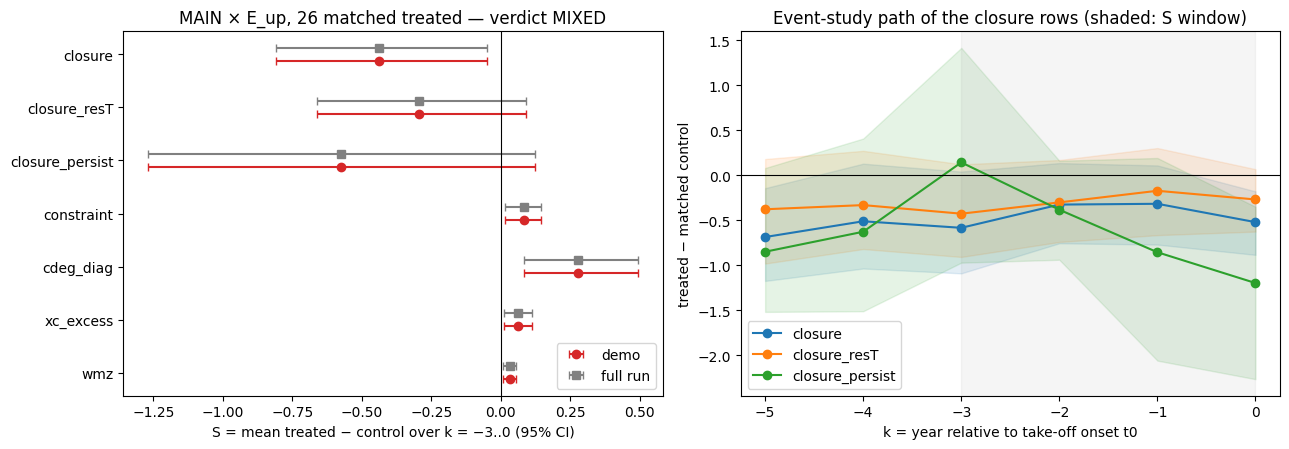

In [24]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4.6))
yy = np.arange(len(show))
for i, c in enumerate(show):
    st = primary["rows"][c]["primary"]
    a1.errorbar(st["S"], i + 0.12, xerr=[[st["S"] - st["ci"][0]], [st["ci"][1] - st["S"]]], fmt="o", color="tab:red",
                capsize=3, label="demo" if i == 0 else None)
    r0 = ref["S"][c]
    a1.errorbar(r0["S"], i - 0.12, xerr=[[r0["S"] - r0["ci"][0]], [r0["ci"][1] - r0["S"]]], fmt="s", color="grey",
                capsize=3, label="full run" if i == 0 else None)
a1.axvline(0, color="k", lw=0.8)
a1.set_yticks(yy, show); a1.invert_yaxis()
a1.set_xlabel("S = mean treated − control over k = −3..0 (95% CI)")
a1.set_title(f"MAIN × E_up, {primary['n_matched']} matched treated — verdict {v['verdict']}")
a1.legend(loc="lower right")

ks = SPEC["es_rel_years"]
for c, col in [("closure", "tab:blue"), ("closure_resT", "tab:orange"), ("closure_persist", "tab:green")]:
    d = np.array(primary["rows"][c]["diff_k"], float)
    ci = np.array(primary["rows"][c]["ci_k"], float)
    a2.plot(ks, d, "-o", color=col, label=c)
    a2.fill_between(ks, ci[:, 0], ci[:, 1], color=col, alpha=0.12)
a2.axhline(0, color="k", lw=0.8)
a2.axvspan(-3, 0, color="grey", alpha=0.08)
a2.set_xlabel("k = year relative to take-off onset t0"); a2.set_ylabel("treated − matched control")
a2.set_title("Event-study path of the closure rows (shaded: S window)")
a2.legend()
plt.tight_layout()
plt.show()

**Reading.** Raw closure is clearly lower before take-off. The turnover-residualised R1a keeps about two thirds
of that effect, so the openness is **not mere churn**. But Burt constraint moves the *other* way (positive), so it
is **not classic brokerage** either. The mechanical verdict is **MIXED**, with flags `underpowered` (fewer than
30 matched treated) and `R1a_model_dependent`. The pattern is cross-community, sparsely closed *top*
neighbourhoods inside a more redundant wider ego network. Confirmation is left to the sealed held-out fold
(`confirm_heldout.py` in the original artifact).